In [1]:
import cooler
import matplotlib.pyplot as plt
import pandas as pd
import pyBigWig
import trackc as tc
from matplotlib import cm

In [2]:
cmap = "RdBu_r"

ZF_IgDn_1k = cooler.Cooler("../raw_data/F-IgD-.allValidPairs.mcool::/resolutions/1000")
ZM_IgDn_1k = cooler.Cooler("../raw_data/M-IgD-.allValidPairs.mcool::/resolutions/1000")
Z_IgDn_1k = cooler.Cooler("../raw_data/Z-IgD-.allValidPairs.mcool::/resolutions/1000")
ZF_naive_1k = cooler.Cooler("../raw_data/F-naive.allValidPairs.mcool::/resolutions/1000")
ZM_naive_1k = cooler.Cooler("../raw_data/M-naive.allValidPairs.mcool::/resolutions/1000")
Z_naive_1k = cooler.Cooler("../raw_data/Z-naive.allValidPairs.mcool::/resolutions/1000")

ZF_IgDn_10k = cooler.Cooler("../raw_data/F-IgD-.allValidPairs.mcool::/resolutions/10000")
ZM_IgDn_10k = cooler.Cooler("../raw_data/M-IgD-.allValidPairs.mcool::/resolutions/10000")
Z_IgDn_10k = cooler.Cooler("../raw_data/Z-IgD-.allValidPairs.mcool::/resolutions/10000")
ZF_naive_10k = cooler.Cooler("../raw_data/F-naive.allValidPairs.mcool::/resolutions/10000")
ZM_naive_10k = cooler.Cooler("../raw_data/M-naive.allValidPairs.mcool::/resolutions/10000")
Z_naive_10k = cooler.Cooler("../raw_data/Z-naive.allValidPairs.mcool::/resolutions/10000")

ZF_IgDn_50k = cooler.Cooler("../raw_data/F-IgD-.allValidPairs.mcool::/resolutions/50000")
ZM_IgDn_50k = cooler.Cooler("../raw_data/M-IgD-.allValidPairs.mcool::/resolutions/50000")
Z_IgDn_50k = cooler.Cooler("../raw_data/Z-IgD-.allValidPairs.mcool::/resolutions/50000")
ZF_naive_50k = cooler.Cooler("../raw_data/F-naive.allValidPairs.mcool::/resolutions/50000")
ZM_naive_50k = cooler.Cooler("../raw_data/M-naive.allValidPairs.mcool::/resolutions/50000")
Z_naive_50k = cooler.Cooler("../raw_data/Z-naive.allValidPairs.mcool::/resolutions/50000")

In [3]:
H3K27ac = pyBigWig.open("../raw_data/ChIP/ENCFF503QQQ.bigWig")
H3K4me3 = pyBigWig.open("../raw_data/ChIP/ENCFF400NSO.bigWig")
H3K4me1 = pyBigWig.open("../raw_data/ChIP/ENCFF245AKP.bigWig")
DNase = pyBigWig.open("../raw_data/ChIP/ENCFF063OUM.bigWig")
CTCF = pyBigWig.open("../raw_data/ChIP/ENCFF219JXX.bigWig")

maxrange: 0.16918167013708574 minrange: 2.6889445724501138e-05
maxrange: 0.10844583687086706 minrange: 1.5943813999469425e-06
maxrange: 0.10980496888890601 minrange: 9.175889240256238e-06
maxrange: 0.058788994041359954 minrange: 2.9209019745297937e-06


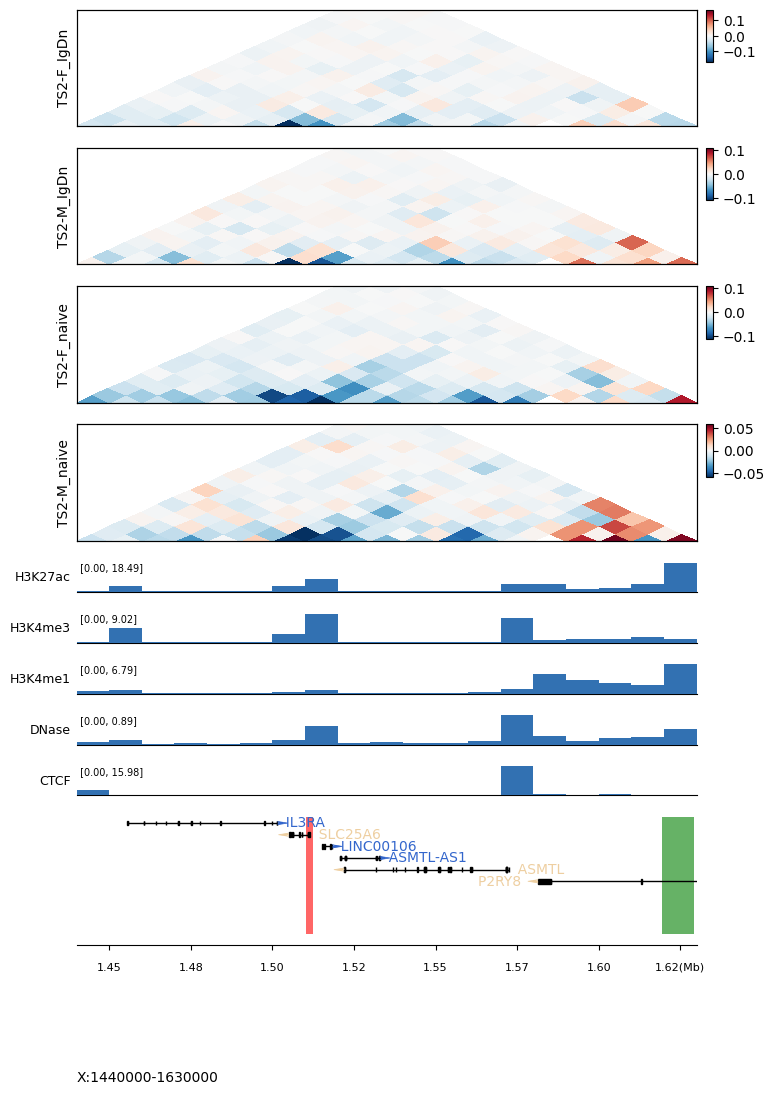

In [4]:
# SLC25A6

gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

fig, axs = tc.make_spec(figsize=(8, 12), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 4], hspace=0.3)

# region = "X:1350000-1630000"
# height = 32
region = "X:1440000-1630000"
height = 16
trim_range = 1

mat_ZF_IgDn_10k = tc.tl.extractCisContact(clr=ZF_IgDn_10k, region=region, extend=0)
mat_ZM_IgDn_10k = tc.tl.extractCisContact(clr=ZM_IgDn_10k, region=region, extend=0)
mat_Z_IgDn_10k = tc.tl.extractCisContact(clr=Z_IgDn_10k, region=region, extend=0)
mat_ZF_naive_10k = tc.tl.extractCisContact(clr=ZF_naive_10k, region=region, extend=0)
mat_ZM_naive_10k = tc.tl.extractCisContact(clr=ZM_naive_10k, region=region, extend=0)
mat_Z_naive_10k = tc.tl.extractCisContact(clr=Z_naive_10k, region=region, extend=0)

mat_ZF_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZF_IgDn_10k / mat_ZF_IgDn_10k.max()
mat_ZM_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZM_IgDn_10k / mat_ZM_IgDn_10k.max()
mat_ZF_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZF_naive_10k / mat_ZF_naive_10k.max()
mat_ZM_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZM_naive_10k / mat_ZM_naive_10k.max()

tc.pl.mapC(ax=axs[0], mat=mat_ZF_IgDn_10k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[1], mat=mat_ZM_IgDn_10k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[2], mat=mat_ZF_naive_10k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[3], mat=mat_ZM_naive_10k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=10000)
tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=10000)
tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=10000)
tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=10000)
tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=10000)

tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:1510270-1512000"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:1512201-1512400"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:1367285-1367933"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:1368332-1368800"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["green"], regions=[region], light_regions=["X:1619494-1629292"])
tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12, regions=region, line=10, gene_fontszie=10)
tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)

plt.savefig('SLC25A6_diff.pdf', format='pdf', bbox_inches='tight')

In [5]:
# # ZFX

# gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

# fig, axs = tc.make_spec(figsize=(8, 12), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 4], hspace=0.3)

# region = "X:23200000-25150000"
# height = 128
# trim_range = 0.99

# mat_ZF_IgDn_10k = tc.tl.extractCisContact(clr=ZF_IgDn_10k, region=region, extend=0)
# mat_ZM_IgDn_10k = tc.tl.extractCisContact(clr=ZM_IgDn_10k, region=region, extend=0)
# mat_Z_IgDn_10k = tc.tl.extractCisContact(clr=Z_IgDn_10k, region=region, extend=0)
# mat_ZF_naive_10k = tc.tl.extractCisContact(clr=ZF_naive_10k, region=region, extend=0)
# mat_ZM_naive_10k = tc.tl.extractCisContact(clr=ZM_naive_10k, region=region, extend=0)
# mat_Z_naive_10k = tc.tl.extractCisContact(clr=Z_naive_10k, region=region, extend=0)

# mat_ZF_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZF_IgDn_10k / mat_ZF_IgDn_10k.max()
# mat_ZM_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZM_IgDn_10k / mat_ZM_IgDn_10k.max()
# mat_ZF_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZF_naive_10k / mat_ZF_naive_10k.max()
# mat_ZM_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZM_naive_10k / mat_ZM_naive_10k.max()

# tc.pl.mapC(ax=axs[0], mat=mat_ZF_IgDn_10k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[1], mat=mat_ZM_IgDn_10k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[2], mat=mat_ZF_naive_10k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[3], mat=mat_ZM_naive_10k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

# tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=10000)
# tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=10000)
# tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=10000)
# tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=10000)
# tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=10000)

# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24162401-24172125"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24151326-24151939"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24071601-24075083"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:25029375-25032086"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["green"], regions=[region], light_regions=["X:23252918-23253716"])
# tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12, regions=region, line=10, gene_fontszie=10)
# tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)

# plt.savefig('ZFX_diff.pdf', format='pdf', bbox_inches='tight')

no max min range
maxrange: 0.04530945821854914 minrange: 0.0001508592417683325
no max min range
maxrange: 0.04557134714814969 minrange: 9.567235272564447e-05
no max min range
maxrange: 0.05924002832192589 minrange: 7.375501534104354e-05
no max min range
maxrange: 0.040373422970503406 minrange: 8.990627729297705e-05


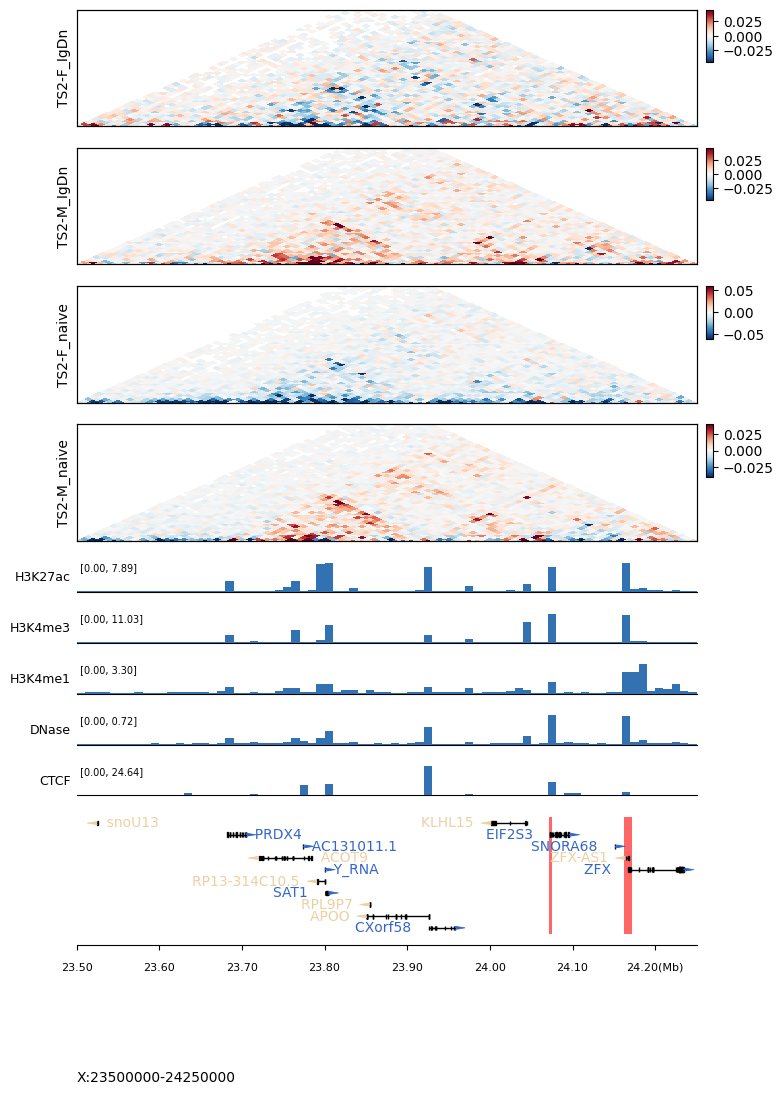

In [6]:
# ZFX

gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

fig, axs = tc.make_spec(figsize=(8, 12), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 4], hspace=0.3)

region = "X:23500000-24250000"
height = 64
trim_range = 0.99

mat_ZF_IgDn_10k = tc.tl.extractCisContact(clr=ZF_IgDn_10k, region=region, extend=0)
mat_ZM_IgDn_10k = tc.tl.extractCisContact(clr=ZM_IgDn_10k, region=region, extend=0)
mat_Z_IgDn_10k = tc.tl.extractCisContact(clr=Z_IgDn_10k, region=region, extend=0)
mat_ZF_naive_10k = tc.tl.extractCisContact(clr=ZF_naive_10k, region=region, extend=0)
mat_ZM_naive_10k = tc.tl.extractCisContact(clr=ZM_naive_10k, region=region, extend=0)
mat_Z_naive_10k = tc.tl.extractCisContact(clr=Z_naive_10k, region=region, extend=0)

mat_ZF_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZF_IgDn_10k / mat_ZF_IgDn_10k.max()
mat_ZM_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZM_IgDn_10k / mat_ZM_IgDn_10k.max()
mat_ZF_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZF_naive_10k / mat_ZF_naive_10k.max()
mat_ZM_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZM_naive_10k / mat_ZM_naive_10k.max()

tc.pl.mapC(ax=axs[0], mat=mat_ZF_IgDn_10k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[1], mat=mat_ZM_IgDn_10k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[2], mat=mat_ZF_naive_10k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[3], mat=mat_ZM_naive_10k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=10000)
tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=10000)
tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=10000)
tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=10000)
tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=10000)

tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24162401-24172125"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24151326-24151939"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24071601-24075083"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:25029375-25032086"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["green"], regions=[region], light_regions=["X:23252918-23253716"])
tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12, regions=region, line=10, gene_fontszie=10)
tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)

plt.savefig('ZFX_diff.pdf', format='pdf', bbox_inches='tight')

no max min range
maxrange: 0.06505241555272047 minrange: 0.0002495978700981748
no max min range
maxrange: 0.06114888246549691 minrange: 0.00021984285307169102
no max min range
maxrange: 0.07019886917527784 minrange: 0.0002300643400272957
no max min range
maxrange: 0.05441283861639731 minrange: 4.770537162484406e-05


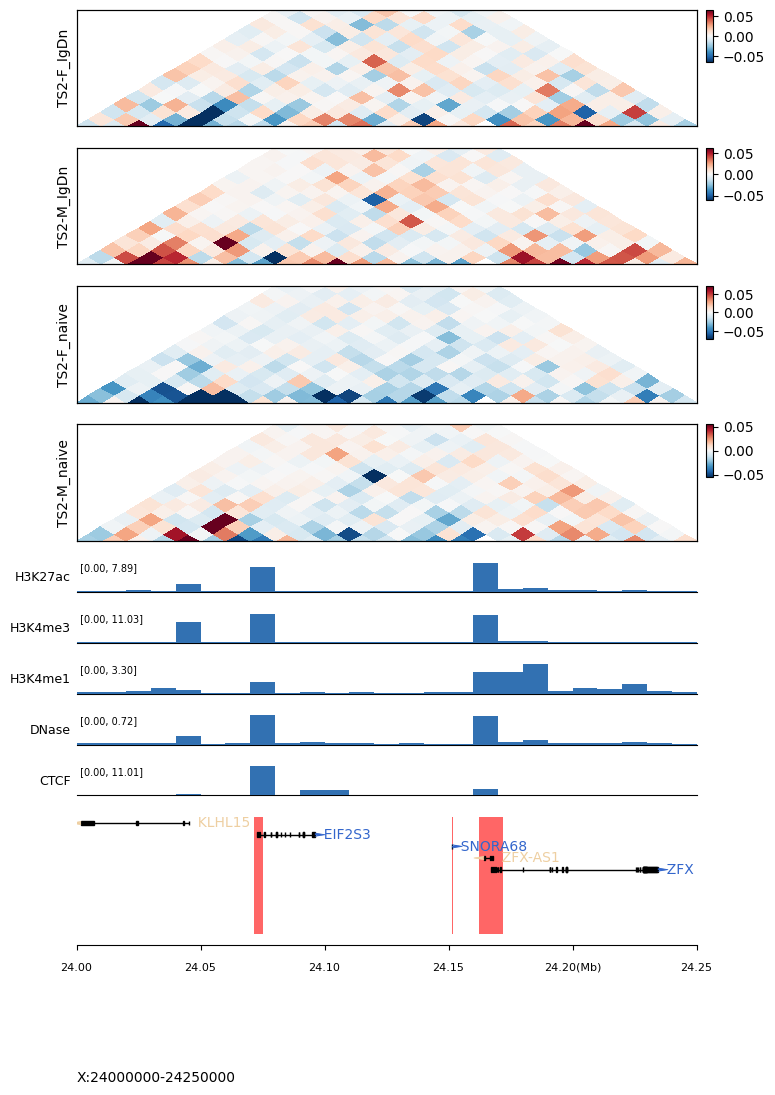

In [7]:
# ZFX

gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

fig, axs = tc.make_spec(figsize=(8, 12), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 4], hspace=0.3)

region = "X:24000000-24250000"
height = 16
trim_range = 0.99

mat_ZF_IgDn_10k = tc.tl.extractCisContact(clr=ZF_IgDn_10k, region=region, extend=0)
mat_ZM_IgDn_10k = tc.tl.extractCisContact(clr=ZM_IgDn_10k, region=region, extend=0)
mat_Z_IgDn_10k = tc.tl.extractCisContact(clr=Z_IgDn_10k, region=region, extend=0)
mat_ZF_naive_10k = tc.tl.extractCisContact(clr=ZF_naive_10k, region=region, extend=0)
mat_ZM_naive_10k = tc.tl.extractCisContact(clr=ZM_naive_10k, region=region, extend=0)
mat_Z_naive_10k = tc.tl.extractCisContact(clr=Z_naive_10k, region=region, extend=0)

mat_ZF_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZF_IgDn_10k / mat_ZF_IgDn_10k.max()
mat_ZM_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZM_IgDn_10k / mat_ZM_IgDn_10k.max()
mat_ZF_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZF_naive_10k / mat_ZF_naive_10k.max()
mat_ZM_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZM_naive_10k / mat_ZM_naive_10k.max()

tc.pl.mapC(ax=axs[0], mat=mat_ZF_IgDn_10k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[1], mat=mat_ZM_IgDn_10k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[2], mat=mat_ZF_naive_10k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[3], mat=mat_ZM_naive_10k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=10000)
tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=10000)
tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=10000)
tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=10000)
tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=10000)

tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24162401-24172125"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24151326-24151939"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24071601-24075083"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:25029375-25032086"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["green"], regions=[region], light_regions=["X:23252918-23253716"])
tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12, regions=region, line=10, gene_fontszie=10)
tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)

plt.savefig('ZFX_diff.pdf', format='pdf', bbox_inches='tight')

In [8]:
# # ZFX

# gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

# fig, axs = tc.make_spec(figsize=(8, 12), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 2], hspace=0.3)

# region = "X:24120000-24240000"
# height = 96
# trim_range = 0.99

# mat_ZF_IgDn_1k = tc.tl.extractCisContact(clr=ZF_IgDn_1k, region=region, extend=0)
# mat_ZM_IgDn_1k = tc.tl.extractCisContact(clr=ZM_IgDn_1k, region=region, extend=0)
# mat_Z_IgDn_1k = tc.tl.extractCisContact(clr=Z_IgDn_1k, region=region, extend=0)
# mat_ZF_naive_1k = tc.tl.extractCisContact(clr=ZF_naive_1k, region=region, extend=0)
# mat_ZM_naive_1k = tc.tl.extractCisContact(clr=ZM_naive_1k, region=region, extend=0)
# mat_Z_naive_1k = tc.tl.extractCisContact(clr=Z_naive_1k, region=region, extend=0)

# mat_ZF_IgDn_1k_diff = mat_Z_IgDn_1k / mat_Z_IgDn_1k.max() - mat_ZF_IgDn_1k / mat_ZF_IgDn_1k.max()
# mat_ZM_IgDn_1k_diff = mat_Z_IgDn_1k / mat_Z_IgDn_1k.max() - mat_ZM_IgDn_1k / mat_ZM_IgDn_1k.max()
# mat_ZF_naive_1k_diff = mat_Z_naive_1k / mat_Z_naive_1k.max() - mat_ZF_naive_1k / mat_ZF_naive_1k.max()
# mat_ZM_naive_1k_diff = mat_Z_naive_1k / mat_Z_naive_1k.max() - mat_ZM_naive_1k / mat_ZM_naive_1k.max()

# tc.pl.mapC(ax=axs[0], mat=mat_ZF_IgDn_1k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[1], mat=mat_ZM_IgDn_1k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[2], mat=mat_ZF_naive_1k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[3], mat=mat_ZM_naive_1k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

# tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=1000)
# tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=1000)
# tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=1000)
# tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=1000)
# tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=1000)

# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24162401-24172125"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24151326-24151939"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:24071601-24075083"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:25029375-25032086"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["green"], regions=[region], light_regions=["X:23252918-23253716"])
# tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12, regions=region, line=10, gene_fontszie=10)
# tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)

# plt.savefig('ZFX_diff.pdf', format='pdf', bbox_inches='tight')

maxrange: 0.12593737275482964 minrange: 0.00011876215898294282
maxrange: 0.17852633477633473 minrange: 2.4834263964698677e-05
maxrange: 0.1918401057152297 minrange: 3.378682764212937e-05
maxrange: 0.13037506603275228 minrange: 2.1610718916582547e-05


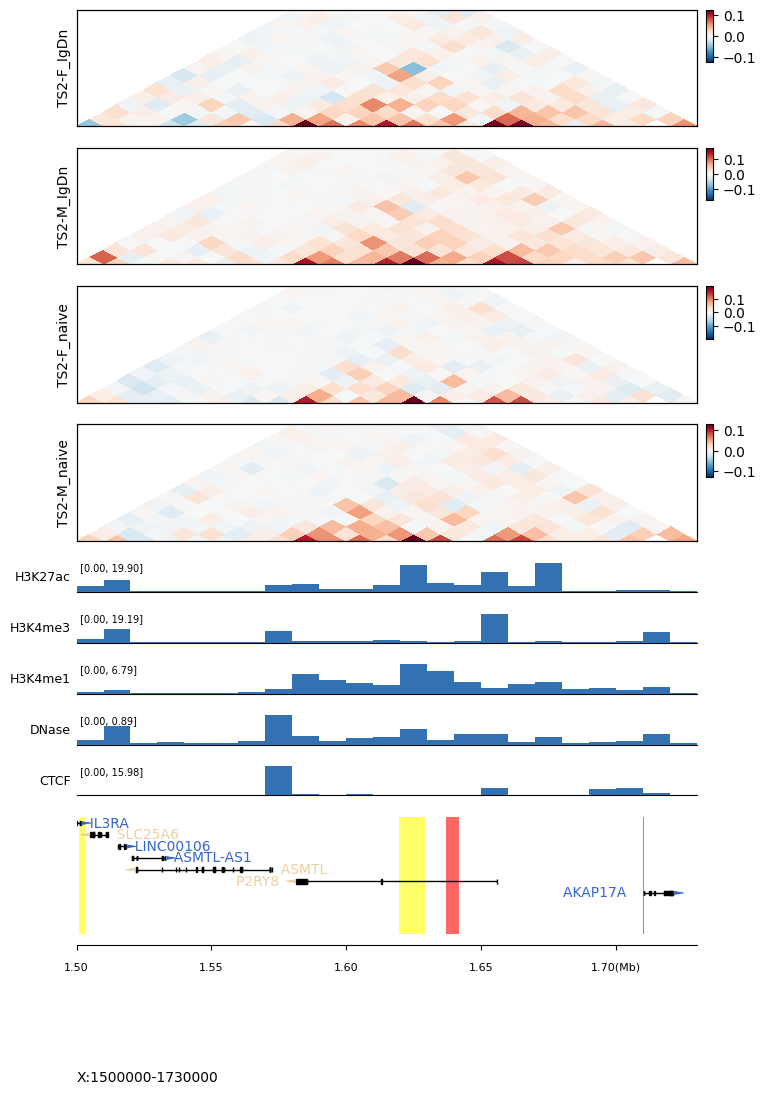

In [9]:
# AKAP17A

gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

fig, axs = tc.make_spec(figsize=(8, 12), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 4], hspace=0.3)

region = "X:1500000-1730000"
height = 16
trim_range = 1

mat_ZF_IgDn_10k = tc.tl.extractCisContact(clr=ZF_IgDn_10k, region=region, extend=0)
mat_ZM_IgDn_10k = tc.tl.extractCisContact(clr=ZM_IgDn_10k, region=region, extend=0)
mat_Z_IgDn_10k = tc.tl.extractCisContact(clr=Z_IgDn_10k, region=region, extend=0)
mat_ZF_naive_10k = tc.tl.extractCisContact(clr=ZF_naive_10k, region=region, extend=0)
mat_ZM_naive_10k = tc.tl.extractCisContact(clr=ZM_naive_10k, region=region, extend=0)
mat_Z_naive_10k = tc.tl.extractCisContact(clr=Z_naive_10k, region=region, extend=0)

mat_ZF_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZF_IgDn_10k / mat_ZF_IgDn_10k.max()
mat_ZM_IgDn_10k_diff = mat_Z_IgDn_10k / mat_Z_IgDn_10k.max() - mat_ZM_IgDn_10k / mat_ZM_IgDn_10k.max()
mat_ZF_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZF_naive_10k / mat_ZF_naive_10k.max()
mat_ZM_naive_10k_diff = mat_Z_naive_10k / mat_Z_naive_10k.max() - mat_ZM_naive_10k / mat_ZM_naive_10k.max()

tc.pl.mapC(ax=axs[0], mat=mat_ZF_IgDn_10k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[1], mat=mat_ZM_IgDn_10k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[2], mat=mat_ZF_naive_10k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[3], mat=mat_ZM_naive_10k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=10000)
tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=10000)
tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=10000)
tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=10000)
tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=10000)

tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:1710001-1710541"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:1637092-1641979"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:1619494-1629292"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:1500895-1503292"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["green"], regions=[region], light_regions=["X:1590942-1591184"])

tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12, regions=region, line=10, gene_fontszie=10)
tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)

plt.savefig('AKAP17A_diff.pdf', format='pdf', bbox_inches='tight')

In [10]:
# # XIST

# gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

# fig, axs = tc.make_spec(figsize=(8, 8), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 2], hspace=0.3)

# region = "X:73030000-73076000"
# height = 32
# trim_range = 1

# mat_ZF_IgDn_1k = tc.tl.extractCisContact(clr=ZF_IgDn_1k, region=region, extend=0)
# mat_ZM_IgDn_1k = tc.tl.extractCisContact(clr=ZM_IgDn_1k, region=region, extend=0)
# mat_Z_IgDn_1k = tc.tl.extractCisContact(clr=Z_IgDn_1k, region=region, extend=0)
# mat_ZF_naive_1k = tc.tl.extractCisContact(clr=ZF_naive_1k, region=region, extend=0)
# mat_ZM_naive_1k = tc.tl.extractCisContact(clr=ZM_naive_1k, region=region, extend=0)
# mat_Z_naive_1k = tc.tl.extractCisContact(clr=Z_naive_1k, region=region, extend=0)

# mat_ZF_IgDn_1k_diff = mat_Z_IgDn_1k / mat_Z_IgDn_1k.max() - mat_ZF_IgDn_1k / mat_ZF_IgDn_1k.max()
# mat_ZM_IgDn_1k_diff = mat_Z_IgDn_1k / mat_Z_IgDn_1k.max() - mat_ZM_IgDn_1k / mat_ZM_IgDn_1k.max()
# mat_ZF_naive_1k_diff = mat_Z_naive_1k / mat_Z_naive_1k.max() - mat_ZF_naive_1k / mat_ZF_naive_1k.max()
# mat_ZM_naive_1k_diff = mat_Z_naive_1k / mat_Z_naive_1k.max() - mat_ZM_naive_1k / mat_ZM_naive_1k.max()

# tc.pl.mapC(ax=axs[0], mat=mat_ZF_IgDn_1k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[1], mat=mat_ZM_IgDn_1k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[2], mat=mat_ZF_naive_1k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[3], mat=mat_ZM_naive_1k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

# tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=1000)
# tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=1000)
# tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=1000)
# tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=1000)
# tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=1000)

# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["red"], regions=[region], light_regions=["X:73070349-73072835"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:73069832-73070332"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:73075481-73075630"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["yellow"], regions=[region], light_regions=["X:73075635-73076035"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["green"], regions=[region], light_regions=["X:73062816-73063035"])

# tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12, regions=region, line=2, gene_fontszie=10)
# tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)
# plt.savefig('XIST_diff.pdf', format='pdf', bbox_inches='tight')

In [11]:
# # XIST

# gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

# fig, axs = tc.make_spec(figsize=(16, 16), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 1], hspace=0.3)

# region = "X:72770066-77640209"
# height = 96
# trim_range = 0.98

# mat_ZF_IgDn_50k = tc.tl.extractCisContact(clr=ZF_IgDn_50k, region=region, extend=0)
# mat_ZM_IgDn_50k = tc.tl.extractCisContact(clr=ZM_IgDn_50k, region=region, extend=0)
# mat_Z_IgDn_50k = tc.tl.extractCisContact(clr=Z_IgDn_50k, region=region, extend=0)
# mat_ZF_naive_50k = tc.tl.extractCisContact(clr=ZF_naive_50k, region=region, extend=0)
# mat_ZM_naive_50k = tc.tl.extractCisContact(clr=ZM_naive_50k, region=region, extend=0)
# mat_Z_naive_50k = tc.tl.extractCisContact(clr=Z_naive_50k, region=region, extend=0)

# mat_ZF_IgDn_50k_diff = mat_Z_IgDn_50k / mat_Z_IgDn_50k.max() - mat_ZF_IgDn_50k / mat_ZF_IgDn_50k.max()
# mat_ZM_IgDn_50k_diff = mat_Z_IgDn_50k / mat_Z_IgDn_50k.max() - mat_ZM_IgDn_50k / mat_ZM_IgDn_50k.max()
# mat_ZF_naive_50k_diff = mat_Z_naive_50k / mat_Z_naive_50k.max() - mat_ZF_naive_50k / mat_ZF_naive_50k.max()
# mat_ZM_naive_50k_diff = mat_Z_naive_50k / mat_Z_naive_50k.max() - mat_ZM_naive_50k / mat_ZM_naive_50k.max()

# tc.pl.mapC(ax=axs[0], mat=mat_ZF_naive_50k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[1], mat=mat_ZM_naive_50k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[2], mat=mat_ZF_IgDn_50k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
# tc.pl.mapC(ax=axs[3], mat=mat_ZM_IgDn_50k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

# tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=10000)
# tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=10000)
# tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=10000)
# tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=10000)
# tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=10000)

# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["grey"], regions=[region], light_regions=["X:73050000-73100000"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["grey"], regions=[region], light_regions=["X:73800000-73850000"])
# tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["grey"], regions=[region], light_regions=["X:77000000-77500000"])

# tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12[gene_bed12[3].isin(["XIST", "TSIX"])], regions=region, line=2, gene_fontszie=10)
# tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)
# plt.savefig('XIST_diff.pdf', format='pdf', bbox_inches='tight')

no max min range
maxrange: 0.060876093878980284 minrange: 9.421004796404415e-05
no max min range
maxrange: 0.07733032716443348 minrange: 6.472612463537947e-05
no max min range
maxrange: 0.03774633968182351 minrange: 0.0001385145697539586
no max min range
maxrange: 0.05412885501595173 minrange: 3.7314128994943296e-05


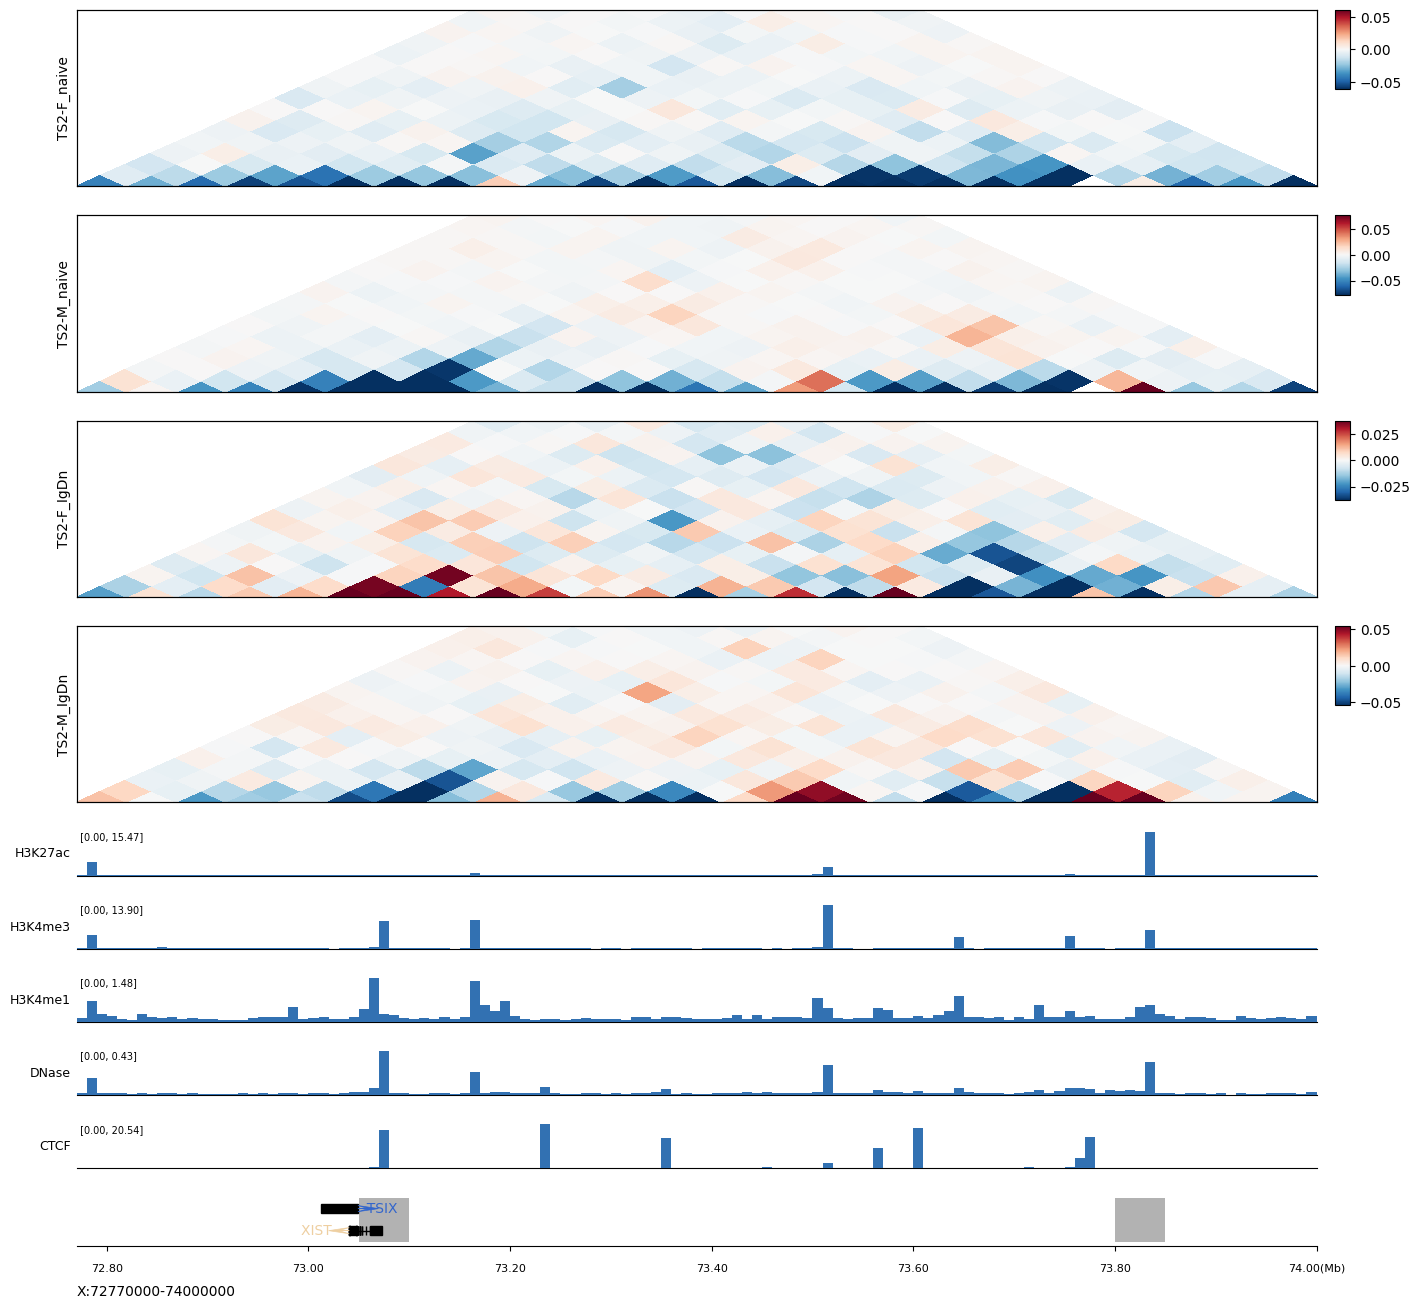

In [12]:
# XIST

gene_bed12 = pd.read_table("../raw_data/Homo_sapiens.GRCh37.75.bed13", header=None)

fig, axs = tc.make_spec(figsize=(16, 16), height_ratios=[4, 4, 4, 4, 1, 1, 1, 1, 1, 1], hspace=0.3)

region = "X:72770000-74000000"
height = 16
trim_range = 0.98

mat_ZF_IgDn_50k = tc.tl.extractCisContact(clr=ZF_IgDn_50k, region=region, extend=0)
mat_ZM_IgDn_50k = tc.tl.extractCisContact(clr=ZM_IgDn_50k, region=region, extend=0)
mat_Z_IgDn_50k = tc.tl.extractCisContact(clr=Z_IgDn_50k, region=region, extend=0)
mat_ZF_naive_50k = tc.tl.extractCisContact(clr=ZF_naive_50k, region=region, extend=0)
mat_ZM_naive_50k = tc.tl.extractCisContact(clr=ZM_naive_50k, region=region, extend=0)
mat_Z_naive_50k = tc.tl.extractCisContact(clr=Z_naive_50k, region=region, extend=0)

mat_ZF_IgDn_50k_diff = mat_Z_IgDn_50k / mat_Z_IgDn_50k.max() - mat_ZF_IgDn_50k / mat_ZF_IgDn_50k.max()
mat_ZM_IgDn_50k_diff = mat_Z_IgDn_50k / mat_Z_IgDn_50k.max() - mat_ZM_IgDn_50k / mat_ZM_IgDn_50k.max()
mat_ZF_naive_50k_diff = mat_Z_naive_50k / mat_Z_naive_50k.max() - mat_ZF_naive_50k / mat_ZF_naive_50k.max()
mat_ZM_naive_50k_diff = mat_Z_naive_50k / mat_Z_naive_50k.max() - mat_ZM_naive_50k / mat_ZM_naive_50k.max()

tc.pl.mapC(ax=axs[0], mat=mat_ZF_naive_50k_diff, label="TS2-F_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[1], mat=mat_ZM_naive_50k_diff, label="TS2-M_naive", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[2], mat=mat_ZF_IgDn_50k_diff, label="TS2-F_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)
tc.pl.mapC(ax=axs[3], mat=mat_ZM_IgDn_50k_diff, label="TS2-M_IgDn", cmap=cmap, map_type="tri", height=height, trim_range=trim_range)

tc.pl.bw_track(H3K27ac, axs[4], regions=[region], label="H3K27ac", binsize=10000)
tc.pl.bw_track(H3K4me3, axs[5], regions=[region], label="H3K4me3", binsize=10000)
tc.pl.bw_track(H3K4me1, axs[6], regions=[region], label="H3K4me1", binsize=10000)
tc.pl.bw_track(DNase, axs[7], regions=[region], label="DNase", binsize=10000)
tc.pl.bw_track(CTCF, axs[8], regions=[region], label="CTCF", binsize=10000)

tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["grey"], regions=[region], light_regions=["X:73050000-73100000"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["grey"], regions=[region], light_regions=["X:73800000-73850000"])
tc.pl.vhighlight(axs=[axs[-1]], alpha=0.6, colors=["grey"], regions=[region], light_regions=["X:77000000-77500000"])

tc.pl.gene_track(ax=axs[-1], bed12=gene_bed12[gene_bed12[3].isin(["XIST", "TSIX"])], regions=region, line=2, gene_fontszie=10)
tc.pl.scale_track(ax=axs[-1], region=region, scale_adjust="Mb", tick_pos="bottom", ratio2ax=1.2)
plt.savefig('XIST_diff.pdf', format='pdf', bbox_inches='tight')